## IMPORTS

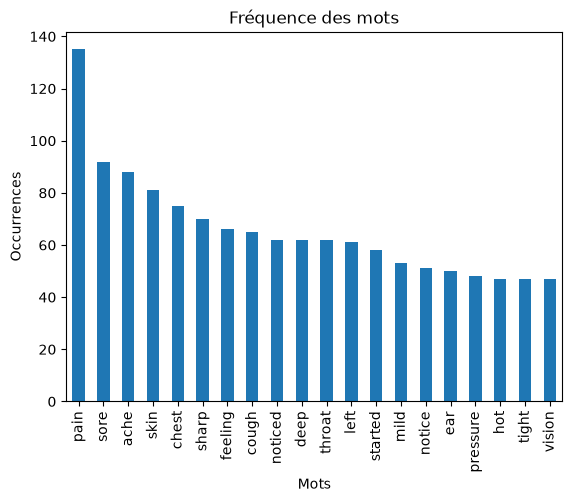

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
import numpy as np
from stop_words import get_stop_words

stop_words = get_stop_words('en')
data = pd.read_csv("../../Student_Clean.csv")
df = data
mots_articles = df.iloc[:, 2].str.replace("’","").str.cat(sep=' ').lower().split()
stopwords = ["im","its","ive","it.","feel","feels"]

words_without_stopwords = [ word for word in mots_articles if word not in stop_words and word not in stopwords ]
frequences = pd.Series(words_without_stopwords).value_counts().head(20)
frequences.plot(kind='bar')


plt.title('Fréquence des mots')
plt.xlabel('Mots')
plt.ylabel('Occurrences')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("../../Student_Clean.csv")

texts = df.iloc[:, 2].fillna("")

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)
inertias = []

kmeans = KMeans(
    n_clusters=3,
    random_state=0,
    n_init="auto"
)

from sklearn.metrics import silhouette_score
scores = {}
for n in range(2, 50):
    kmeans = KMeans(
        n_clusters=n,
        random_state=0,
        n_init="auto"
    )
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores[f"{n}"] = score

highest_key = max(scores, key=scores.get)

print(highest_key)


kmeans = KMeans(
        n_clusters=12,
        random_state=0,
        n_init="auto"
    )

labels = kmeans.fit_predict(X)

print(kmeans.labels_)



2 clusters : 0.007
3 clusters : 0.009
4 clusters : 0.009
5 clusters : 0.010
6 clusters : 0.011
7 clusters : 0.014
8 clusters : 0.014
9 clusters : 0.017
10 clusters : 0.018
11 clusters : 0.019
12 clusters : 0.020
13 clusters : 0.019
14 clusters : 0.020
15 clusters : 0.020
16 clusters : 0.019
17 clusters : 0.019
18 clusters : 0.019
19 clusters : 0.019
20 clusters : 0.017
21 clusters : 0.017
22 clusters : 0.018
23 clusters : 0.016
24 clusters : 0.016
25 clusters : 0.015
26 clusters : 0.015
27 clusters : 0.015
28 clusters : 0.015
29 clusters : 0.016
30 clusters : 0.015
31 clusters : 0.014
32 clusters : 0.014
33 clusters : 0.014
34 clusters : 0.014
35 clusters : 0.013
36 clusters : 0.012
37 clusters : 0.011
38 clusters : 0.011
39 clusters : 0.011
40 clusters : 0.011
41 clusters : 0.011
42 clusters : 0.011
43 clusters : 0.011
44 clusters : 0.012
45 clusters : 0.012
46 clusters : 0.012
47 clusters : 0.012
48 clusters : 0.012
49 clusters : 0.012
15
[2 9 0 ... 2 7 2]


## Elbow method